In [ ]:
from google.colab import drive

# Mount google drive
drive.mount('/content/drive')

Mounted at /content/drive


Copy dataset from google drive to local colab environment

Link to dataset: https://www.kaggle.com/datasets/alistairking/recyclable-and-household-waste-classification

In [ ]:
import os

# Define the path to your zipped file in Google Drive
zipped_file_path = '/content/drive/MyDrive/WasteDataset.zip'

# Define the destination directory in your Colab environment
dataset_path = '/content/dataset/'

# Create the destination directory if it doesn't exist
os.makedirs(dataset_path, exist_ok=True)

In [ ]:
# Copy the zipped file to the local Colab environment
!cp "{zipped_file_path}" "{dataset_path}"

In [ ]:
# Change to the destination directory
%cd "{dataset_path}"

!unzip -qq "{os.path.basename(zipped_file_path)}"

# Go back to the original content directory
%cd /content

/content/dataset
/content


In [ ]:
# List the contents of the unzipped directory
!ls -F "{dataset_path}"

images/  README.txt  WasteDataset.zip


### Preprocess and load images
Note: Trying to load all images into memory at once consumes too much RAM, so images are loaded through their paths dynamically using tf dataset

In [ ]:
import tensorflow as tf
import os

In [ ]:
# Settings
dataset_root = "/content/dataset/images/images"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
VAL_SPLIT = 0.1 # 10% validation
TEST_SPLIT = 0.1 # 10% test
SEED = 42

In [ ]:
# Training dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_root,
    validation_split=VAL_SPLIT + TEST_SPLIT, # 20% reserved for val+test
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical" # one-hot encoded labels
)

# Temp dataset: 20% reserved for val+test
temp_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_root,
    validation_split=VAL_SPLIT + TEST_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

Found 15000 files belonging to 30 classes.
Using 12000 files for training.
Found 15000 files belonging to 30 classes.
Using 3000 files for validation.


In [ ]:
# Convert to a list of batches for splitting
temp_images = []
temp_labels = []

for images, labels in temp_dataset:
    temp_images.append(images)
    temp_labels.append(labels)

# Concatenate all batches
temp_images = tf.concat(temp_images, axis=0)
temp_labels = tf.concat(temp_labels, axis=0)

# Compute split indices
num_temp = temp_images.shape[0]
num_val = int(num_temp * (VAL_SPLIT / (VAL_SPLIT + TEST_SPLIT)))

X_val = temp_images[:num_val]
y_val = temp_labels[:num_val]

X_test = temp_images[num_val:]
y_test = temp_labels[num_val:]

# Convert back to tf.data.Dataset
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [ ]:
class_names = train_dataset.class_names
idx_to_class = {i: name for i, name in enumerate(class_names)}

print("Num Classes: ", len(class_names))
print("Classes:", class_names)
print("Number of training batches:", tf.data.experimental.cardinality(train_dataset).numpy())

Num Classes:  30
Classes: ['aerosol_cans', 'aluminum_food_cans', 'aluminum_soda_cans', 'cardboard_boxes', 'cardboard_packaging', 'clothing', 'coffee_grounds', 'disposable_plastic_cutlery', 'eggshells', 'food_waste', 'glass_beverage_bottles', 'glass_cosmetic_containers', 'glass_food_jars', 'magazines', 'newspaper', 'office_paper', 'paper_cups', 'plastic_cup_lids', 'plastic_detergent_bottles', 'plastic_food_containers', 'plastic_shopping_bags', 'plastic_soda_bottles', 'plastic_straws', 'plastic_trash_bags', 'plastic_water_bottles', 'shoes', 'steel_food_cans', 'styrofoam_cups', 'styrofoam_food_containers', 'tea_bags']
Number of training batches: 375


### Data Augmentation

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.2)
])

# Apply augmentation to training dataset
augmented_train_dataset = train_dataset.map(lambda x, y: (data_augmentation(x, training=True), y))
augmented_train_dataset = augmented_train_dataset.prefetch(tf.data.AUTOTUNE)

In [ ]:
def count_images(dataset):
    count = 0
    for images, _ in dataset:
        count += images.shape[0]
    return count

In [ ]:
# Final full datasets to use
print("Train Dataset: ", train_dataset)
print("Augmented Train Dataset: ", augmented_train_dataset)
print("Train images count:", count_images(train_dataset))

print("Val Dataset: ", val_dataset)
print("Val images count:", count_images(val_dataset))

print("Test Dataset: ", test_dataset)
print("Test images count:", count_images(test_dataset))

Train Dataset:  <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 30), dtype=tf.float32, name=None))>
Augmented Train Dataset:  <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 30), dtype=tf.float32, name=None))>
Train images count: 12000
Val Dataset:  <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 30), dtype=tf.float32, name=None))>
Val images count: 1500
Test Dataset:  <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 30), dtype=tf.float32, name=None))>
Test images count: 1500


In [ ]:
# Small datasets to use for testing
# small_train_dataset = train_dataset.take(100)
# small_augmented_train_dataset = augmented_train_dataset.take(100)
# small_val_dataset = val_dataset.take(100)
# small_test_dataset = test_dataset.take(100)

# print("Small train dataset size: ", count_images(small_train_dataset))
# print("Small augmented train dataset size: ", count_images(small_augmented_train_dataset))
# print("Small val dataset size: ", count_images(small_val_dataset))
# print("Small test dataset size: ", count_images(small_test_dataset))

# Visualize the data

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def show_images(dataset, class_names=None):
    plt.figure(figsize=(8, 8))

    # Take one batch only
    for images, labels in dataset.take(1):
        for i in range(9):
            plt.subplot(3, 3, i + 1)
            plt.imshow(images[i].numpy().astype("uint8"))

            if class_names is not None:
                label_idx = np.argmax(labels[i])
                plt.title(class_names[label_idx])

            plt.axis("off")

    plt.tight_layout()
    plt.show()


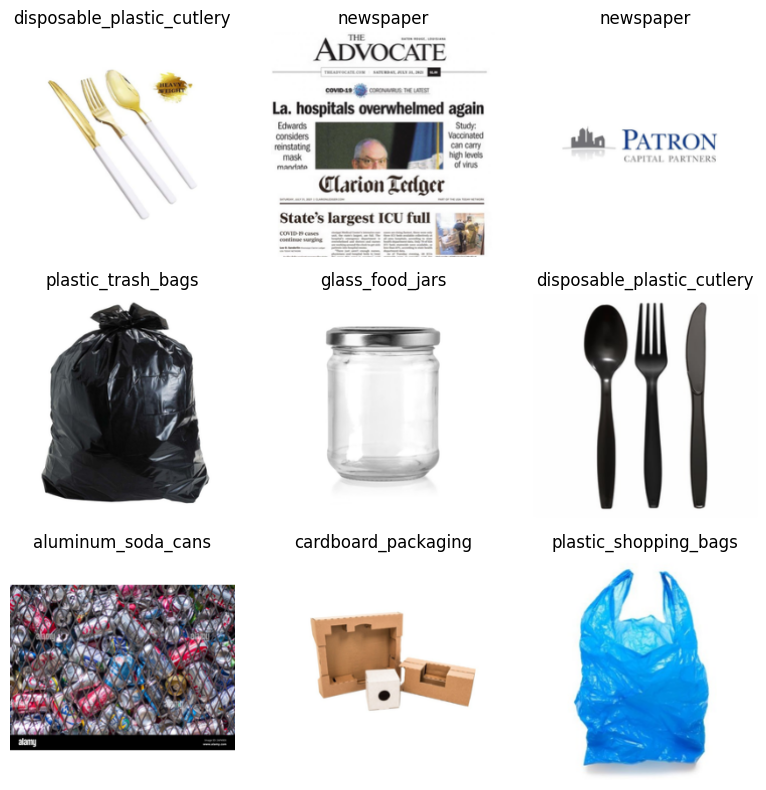

In [ ]:
show_images(train_dataset, class_names)

# Create the model

### Create small model

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

inputs = keras.Input(shape=(IMG_SIZE + (3,)))
x = layers.Rescaling(1./255)(inputs)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.Flatten()(x)
outputs = layers.Dense(len(class_names), activation="softmax")(x)

model = keras.Model(inputs=inputs, outputs=outputs)

In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 30)             │       768,030 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,746,526 (6.66 MB)

 Trainable params: 1,746,526 (6.66 MB)

 Non-trainable params: 0 (0.00 B)

### Compile and train

In [ ]:
# Choose loss function, optimizer, and metrics
model.compile(loss="categorical_crossentropy", optimizer="rmsprop", metrics=["accuracy"])

# Callback function to save best model during training
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="model.keras",
        save_best_only=True,
        monitor="val_loss"
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
]

In [ ]:
# Train the model without augmentation
history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=val_dataset,
    callbacks=callbacks
)

Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 37s 76ms/step - accuracy: 0.1255 - loss: 3.1179 - val_accuracy: 0.2473 - val_loss: 2.6094
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 28s 74ms/step - accuracy: 0.3169 - loss: 2.4562 - val_accuracy: 0.3960 - val_loss: 2.1249
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 37s 64ms/step - accuracy: 0.4742 - loss: 1.9021 - val_accuracy: 0.4833 - val_loss: 1.9034
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 26s 68ms/step - accuracy: 0.6003 - loss: 1.4160 - val_accuracy: 0.5487 - val_loss: 1.8127
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 68ms/step - accuracy: 0.7096 - loss: 1.0083 - val_accuracy: 0.5693 - val_loss: 2.0667
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 68ms/step - accuracy: 0.8017 - loss: 0.6837 - val_accuracy: 0.6287 - val_loss: 1.9417
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 68ms/step - accuracy: 0.8591 - loss: 0.4801 - val_accuracy: 0.6653 - val_loss: 2.1688
Epoch 8/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 26s 69ms/step - accuracy: 0.8930 - loss: 0.3600 - 

### Display loss curve

In [ ]:
import matplotlib.pyplot as plt

def plot_loss_acc_training(history):
  accuracy = history.history["accuracy"]
  val_accuracy = history.history["val_accuracy"]
  loss = history.history["loss"]
  val_loss = history.history["val_loss"]
  epochs = range(1, len(accuracy) + 1)

  plt.plot(epochs, accuracy, "bo", label="Training accuracy")
  plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
  plt.title("Training and validation accuracy")
  plt.legend()
  plt.figure()

  plt.plot(epochs, loss, "bo", label="Training loss")
  plt.plot(epochs, val_loss, "b", label="Validation loss")
  plt.title("Training and validation loss")
  plt.legend()
  plt.show()

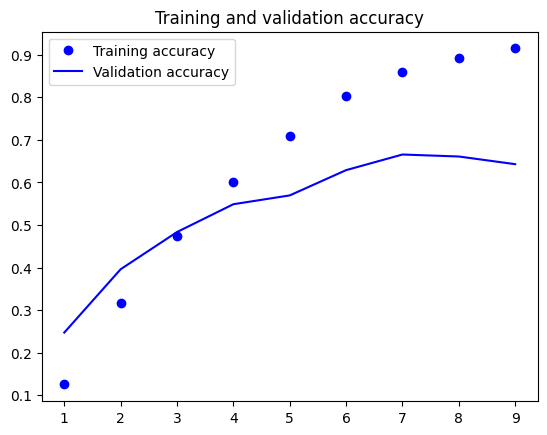

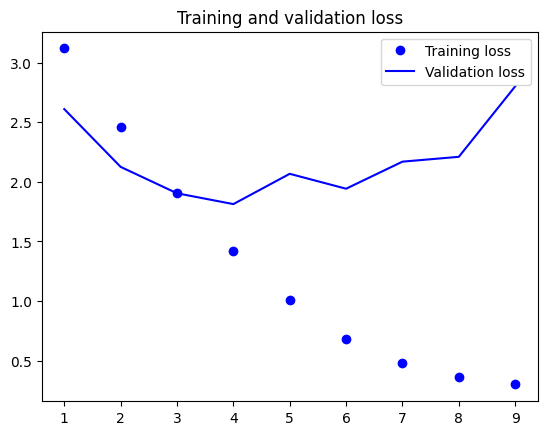

In [ ]:
plot_loss_acc_training(history)

## Evaluate the model

In [ ]:
test_model = keras.models.load_model("model.keras")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.5347 - loss: 1.9074
Test accuracy: 0.535


In [ ]:
def plot_predictions_grid(model, dataset, class_names, num_images=9):
    cols = 3
    rows = (num_images + cols - 1) // cols

    # Randomly grab one batch from the dataset
    images, true_labels = next(iter(
      test_dataset.unbatch().shuffle(buffer_size=1000).batch(num_images)
    ))

    images = images.numpy()
    true_labels = true_labels.numpy()

    plt.figure(figsize=(cols * 3, rows * 3))

    for i in range(num_images):
        img_array = np.expand_dims(images[i], axis=0)
        predictions = model.predict(img_array, verbose=0)
        predicted_index = np.argmax(predictions[0])
        confidence = np.max(predictions[0]) * 100

        plt.subplot(rows, cols, i + 1)
        plt.imshow(images[i].astype("uint8") if images[i].max() > 1 else images[i], cmap="gray")
        plt.axis("off")

        title = f"{class_names[predicted_index]} ({confidence:.1f}%)"
        true_label_i = int(np.argmax(true_labels[i]))
        color = "green" if predicted_index == true_label_i else "red"
        plt.title(title + f"\n[{class_names[true_label_i]}]", color=color, fontsize=10)

    plt.tight_layout()
    plt.show()

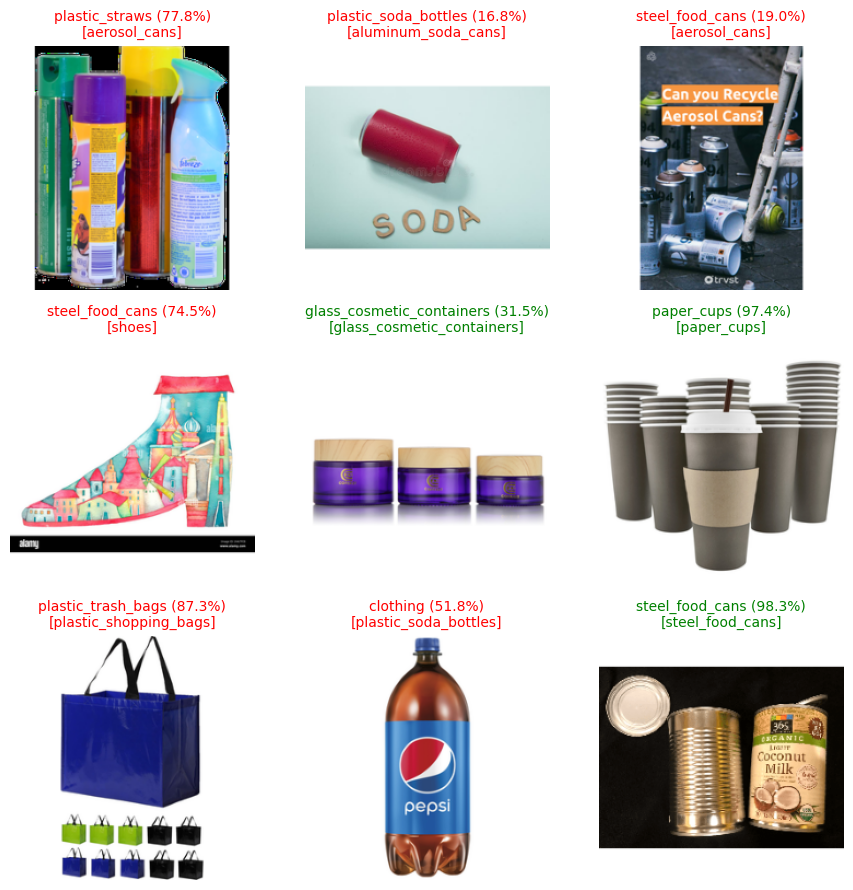

In [ ]:
plot_predictions_grid(model, test_dataset, class_names, num_images=9)